# [LAB-07] 7-사후검정 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## 문제 1

앞 단원에서 진행한 reading 데이터 셋에 대하여 세 가지 독서 방법에 따라 독서 점수의 평균에 차이가 있다면 구체적으로 어떤 차이가 있는지 검정하라.

In [2]:
df1 = load_data("reading")
df1.head()

📚 유아들을 대상으로 세 가지 읽는 방법을 비교,실험하여 얻은 독서평가 점수 데이터 (출처: 방송통신대학교 통계학개론)


,독서방법,점수
0,B,7.700
1,B,1.500
2,B,4.300
3,B,5.400
4,B,4.300


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B vs. D: Custom statistical test, P_val:3.400e-01
D vs. G: Custom statistical test, P_val:4.031e-04
B vs. G: Custom statistical test, P_val:8.764e-05


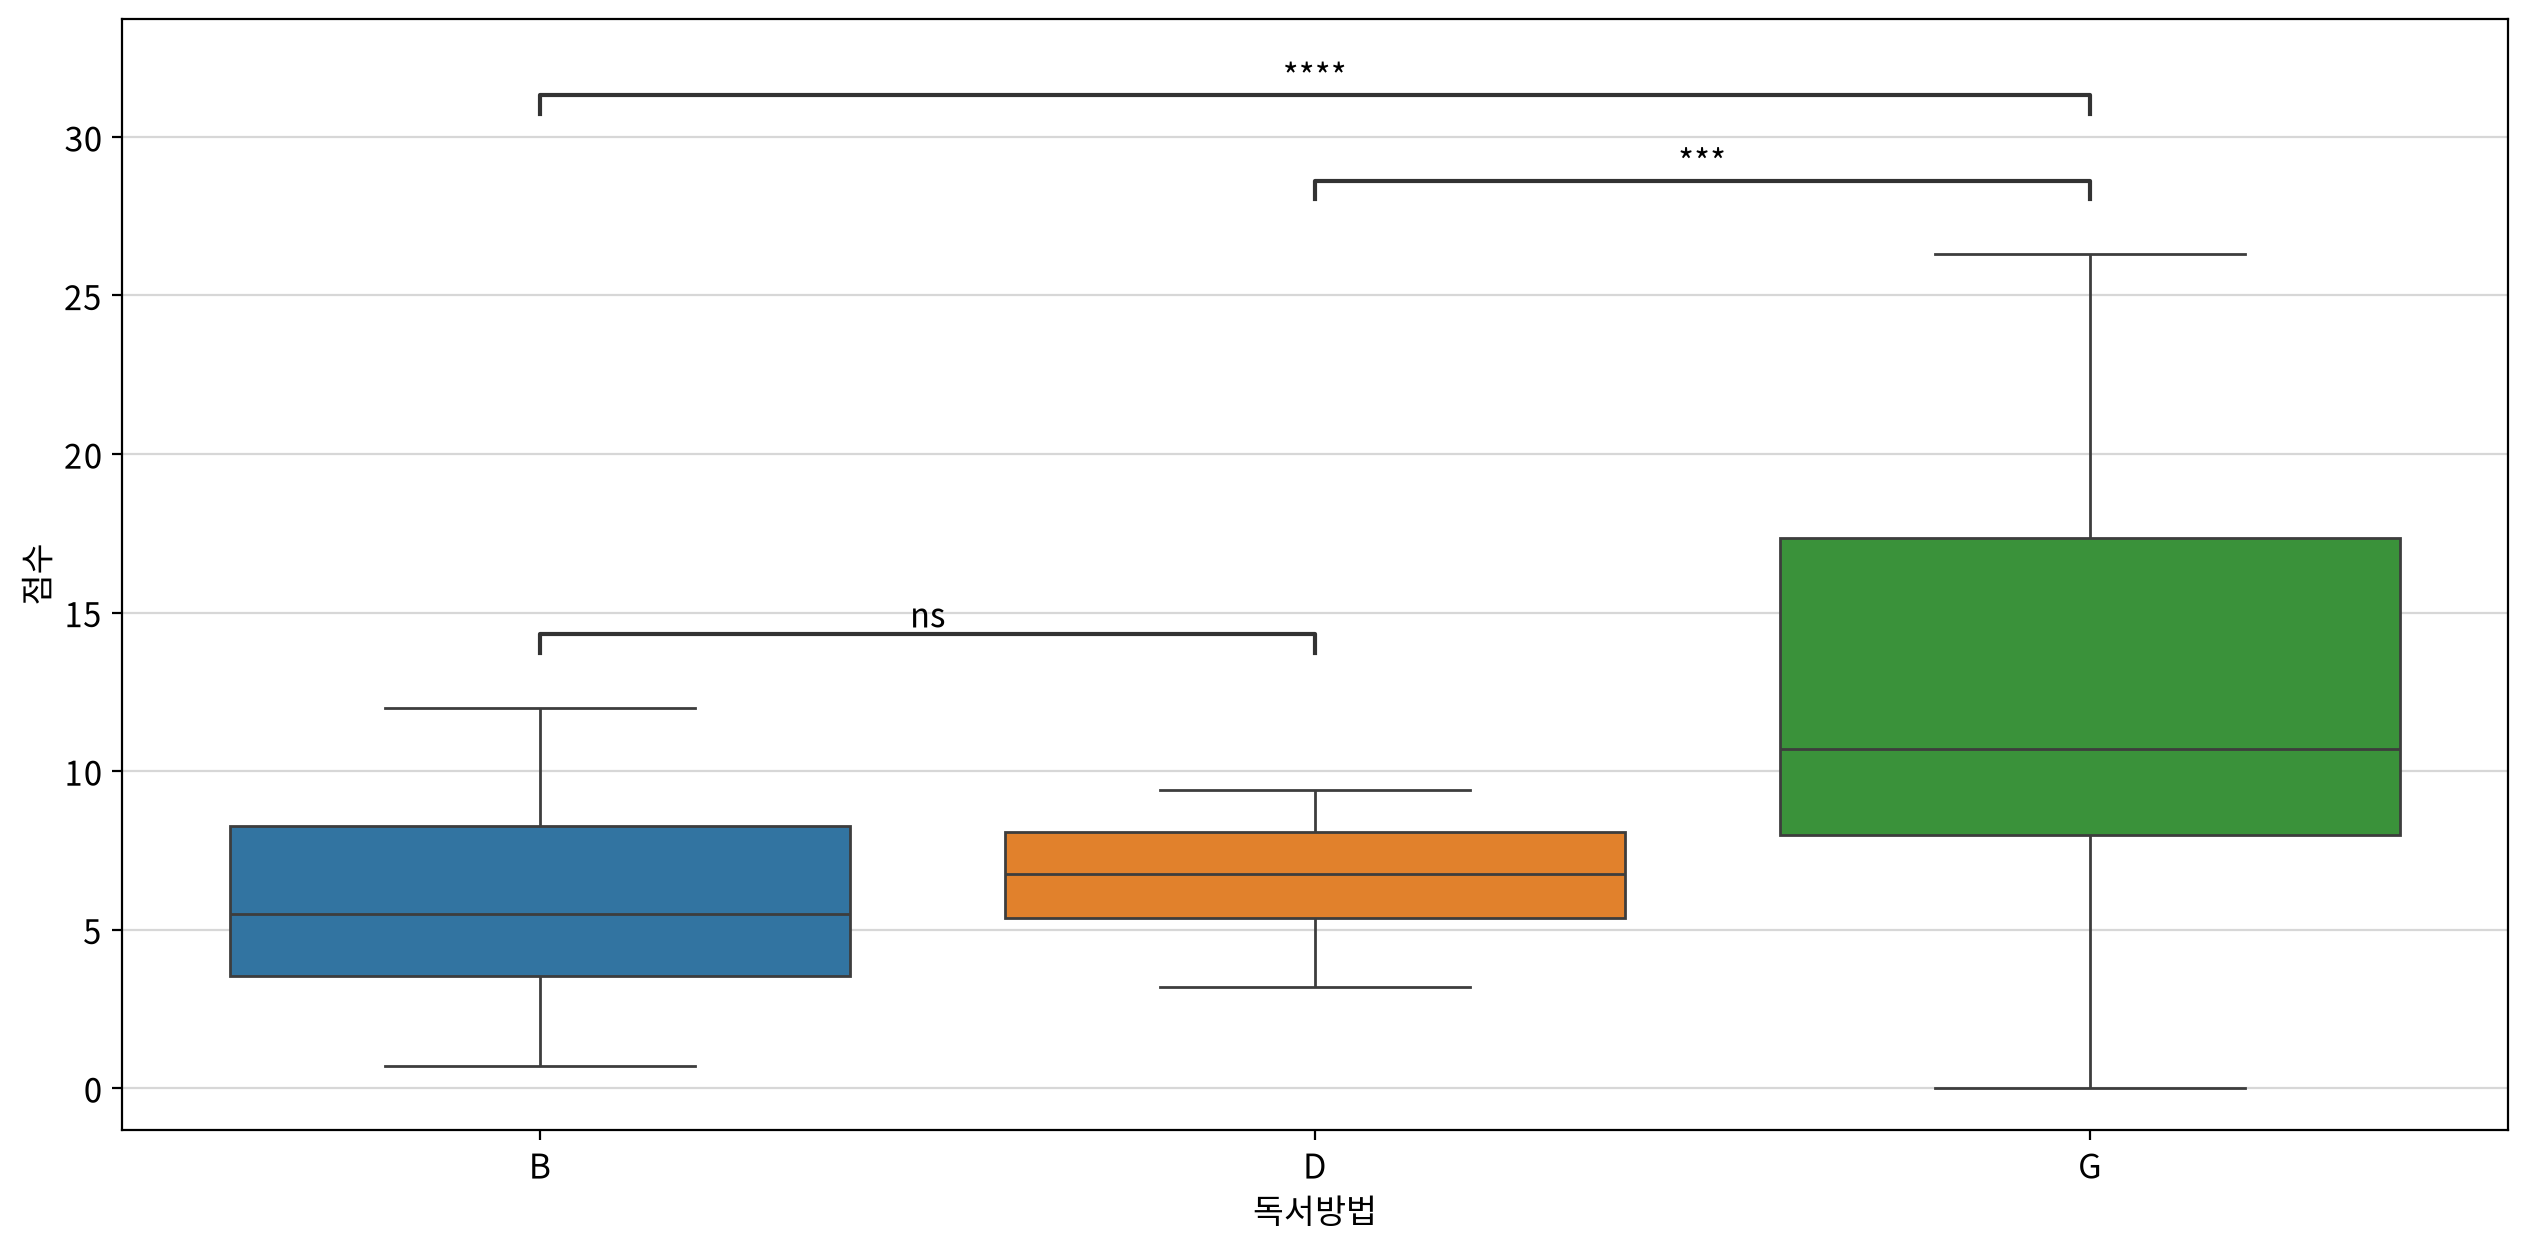

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,B,D,5.732,6.693,-0.961,0.677,-1.421,40.563,0.340,-0.376,False,Small
1,Games-Howell,B,G,5.732,12.531,-6.799,1.457,-4.666,42.964,0.000,-1.137,True,Large
2,Games-Howell,D,G,6.693,12.531,-5.838,1.363,-4.284,34.361,0.000,-1.044,True,Large


In [3]:
my_stats.posthoc_oneway(df1, y='점수', between='독서방법')

### 💡인사이트

- **가정 확인**: `posthoc_oneway`는 등분산성 검정 결과에 따라 사후검정 방법을 선택한다. 결과표의 `test`가 **`Games-Howell`**로 출력되었으므로, **등분산성 가정이 위배**되어 등분산을 가정하지 않는 Games-Howell 검정이 사용되었다. (등분산이 충족되면 Tukey HSD가 선택된다.)
- **집단별 평균**: G(12.531) > D(6.693) > B(5.732) 순으로, G 방법의 점수가 가장 높다.
- **구체적 차이(유의한 쌍)**:
  - **B vs G**: 평균차 −6.799, p ≈ 0.000 → 유의. 효과크기 hedges = −1.137 (**Large**)
  - **D vs G**: 평균차 −5.838, p ≈ 0.000 → 유의. 효과크기 hedges = −1.044 (**Large**)
- **차이 없는 쌍**: **B vs D**는 평균차 −0.961, p = 0.340 으로 유의하지 않다(효과크기도 −0.376, Small).
- **결론**: 독서방법 간 차이는 **G 방법이 B·D 방법보다 점수가 유의하게(그리고 큰 효과로) 높기 때문에 발생**한 것이며, B와 D 사이에는 유의한 차이가 없다.


## 문제 2

앞 단원에서 진행한 2023년 서울시 상권 매출액 데이터를 사용하여 상권 종류에 따라 평균 매출액에 차이가 있다면 구체적으로 어떤 차이가 있는지 검정하라.

In [4]:
df2 = load_data("commercial")
df2.head()

📚 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료 (출처: 서울 열린데이터 광장)


,quarter,code,type,name,sales_amount,number_of_sales
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

골목상권 vs. 관광특구: Custom statistical test, P_val:6.410e-09
관광특구 vs. 발달상권: Custom statistical test, P_val:7.128e-07
발달상권 vs. 전통시장: Custom statistical test, P_val:0.000e+00
골목상권 vs. 발달상권: Custom statistical test, P_val:0.000e+00
관광특구 vs. 전통시장: Custom statistical test, P_val:1.140e-08
골목상권 vs. 전통시장: Custom statistical test, P_val:0.000e+00


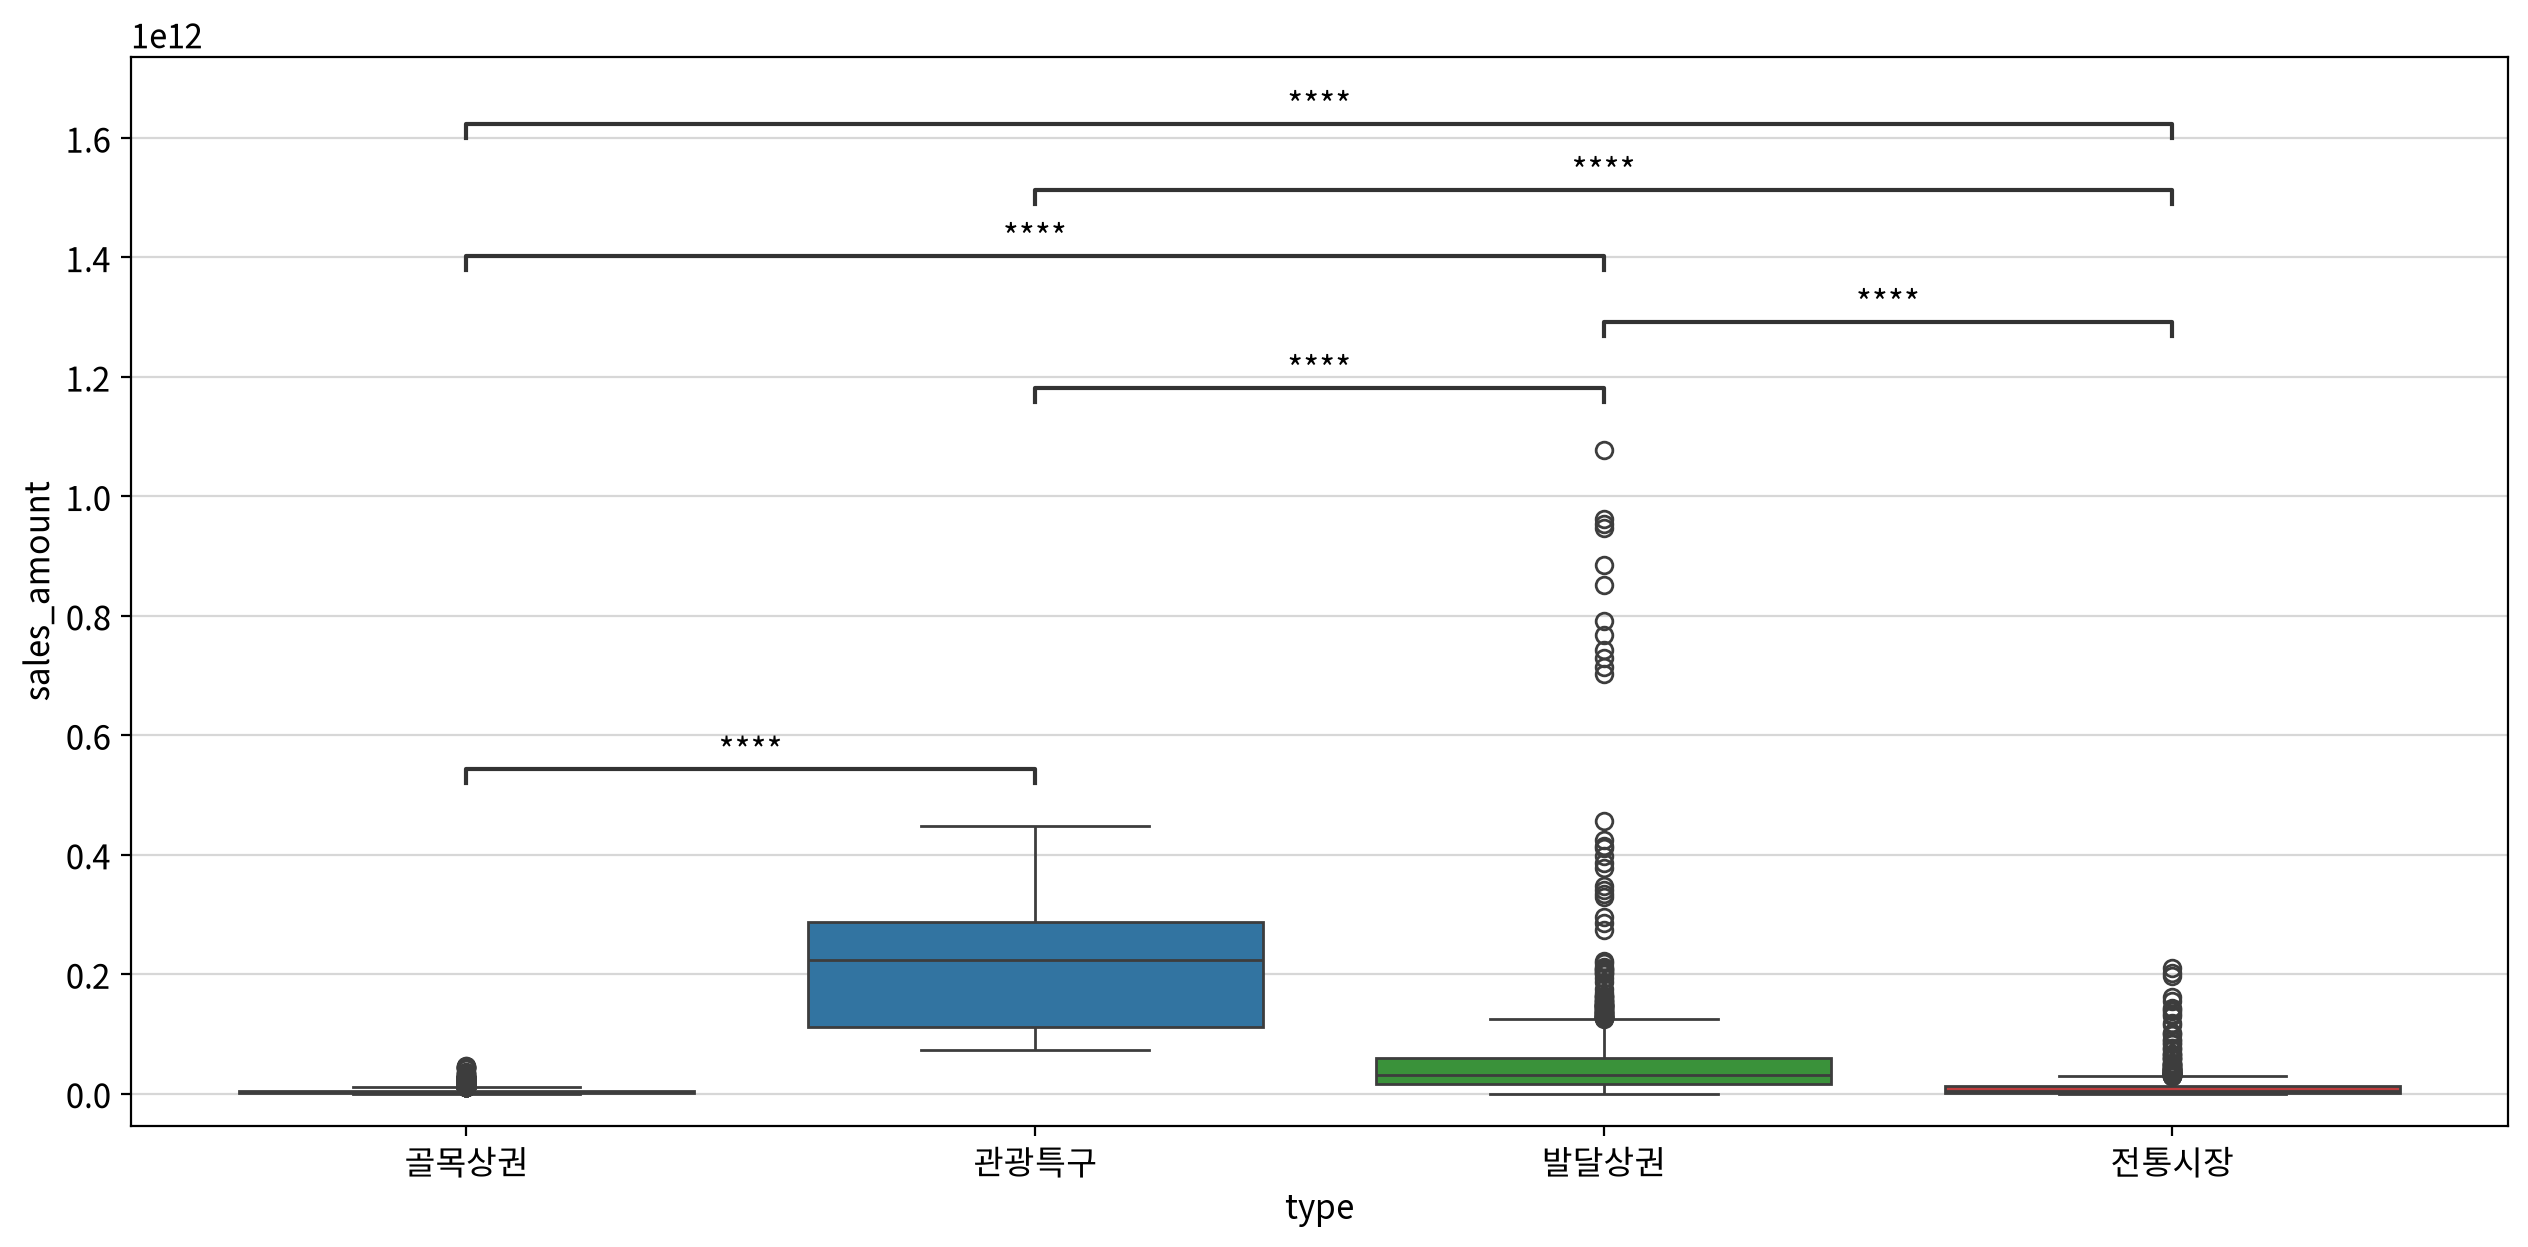

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,골목상권,관광특구,3659508698.643,228143191041.625,-224483682342.982,22892159577.450,-9.806,23.001,0.000,-23.207,True,Large
1,Games-Howell,골목상권,발달상권,3659508698.643,57063096491.533,-53403587792.891,3282877885.264,-16.267,996.055,0.000,-1.160,True,Large
2,Games-Howell,골목상권,전통시장,3659508698.643,10584197874.740,-6924689176.098,606055894.461,-11.426,1143.188,0.000,-0.679,True,Medium
3,Games-Howell,관광특구,발달상권,228143191041.625,57063096491.533,171080094550.092,23126107295.058,7.398,23.955,0.000,1.647,True,Large
4,Games-Howell,관광특구,전통시장,228143191041.625,10584197874.740,217558993166.885,22899931335.272,9.500,23.032,0.000,8.537,True,Large
5,Games-Howell,발달상권,전통시장,57063096491.533,10584197874.740,46478898616.793,3336640863.245,13.930,1061.850,0.000,0.639,True,Medium


In [5]:
my_stats.posthoc_oneway(df2, y='sales_amount', between='type')

### 💡인사이트

- **가정 확인**: 결과표의 `test`가 **`Games-Howell`**로 출력되었으므로, 상권 종류별 매출액의 **등분산성 가정이 위배**되어 Games-Howell 사후검정이 사용되었다.
- **집단별 평균 매출액**: 관광특구(약 2,281억) ≫ 발달상권(약 571억) > 전통시장(약 106억) > 골목상권(약 37억) 순이다.
- **구체적 차이**: **6개 상권 쌍이 모두 p ≈ 0.000 으로 유의**하여, 모든 상권 종류가 서로 매출액 수준이 다르다.
  - 효과크기가 특히 큰 쌍: 관광특구 vs 전통시장(hedges 8.537), 골목상권 vs 관광특구(−23.207), 관광특구 vs 발달상권(1.647), 골목상권 vs 발달상권(−1.160) → 모두 **Large**
  - 상대적으로 작은 쌍: 골목상권 vs 전통시장(−0.679), 발달상권 vs 전통시장(0.639) → **Medium** (그래도 유의함)
- **결론**: 상권 종류별 매출액은 **모든 조합에서 서로 통계적으로 유의하게 다르며**, 특히 **관광특구의 매출액이 압도적으로 높고 골목상권이 가장 낮다.** 차이를 만드는 핵심 축은 관광특구의 높은 매출이다.


## 문제 3

tips 데이터 셋은 식당 고객의 결제 금액, 팁, 성별, 흡연 여부, 요일, 시간대, 일행 규모 등 기본 정보를 담은 데이터이다.

이 데이터를 활용하여 요일별로 주문금액(total_bills)에 차이가 있는지 검정 확인하고 차이가 있다면 구체적으로 어떤 차이가 있는지 검정하라.


In [6]:
df4 = load_data("tips")
df4.head()

📚 식당 고객의 결제 금액, 팁, 성별, 흡연 여부, 요일, 시간대, 일행 규모 등 기본 정보를 담은 데이터 분석·시각화 실습용 샘플 데이터 (출처: https://www.kaggle.com/datasets/sakshisatre/tips-dataset)

field       description
----------  -------------
total_bill  총 결제 금액
tip         팁 금액
sex         성별
smoker      흡연 여부
day         방문 요일
time        방문 시간대
size        일행 규모



,total_bill,tip,sex,smoker,day,time,size
0,16.990,1.010,Female,No,Sun,Dinner,2
1,10.340,1.660,Male,No,Sun,Dinner,3
2,21.010,3.500,Male,No,Sun,Dinner,3
3,23.680,3.310,Male,No,Sun,Dinner,2
4,24.590,3.610,Female,No,Sun,Dinner,4


### 요일별 주문금액 차이 확인

In [7]:
my_stats.anova_oneway(df4, y='total_bill', between='day')

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,anova,day,3,240,2.767,0.042,0.033,Small


### 구체적인 차이 확인

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Fri vs. Sat: Custom statistical test, P_val:4.541e-01
Sat vs. Sun: Custom statistical test, P_val:8.968e-01
Sun vs. Thur: Custom statistical test, P_val:6.678e-02
Fri vs. Sun: Custom statistical test, P_val:2.371e-01
Sat vs. Thur: Custom statistical test, P_val:2.374e-01
Fri vs. Thur: Custom statistical test, P_val:9.957e-01


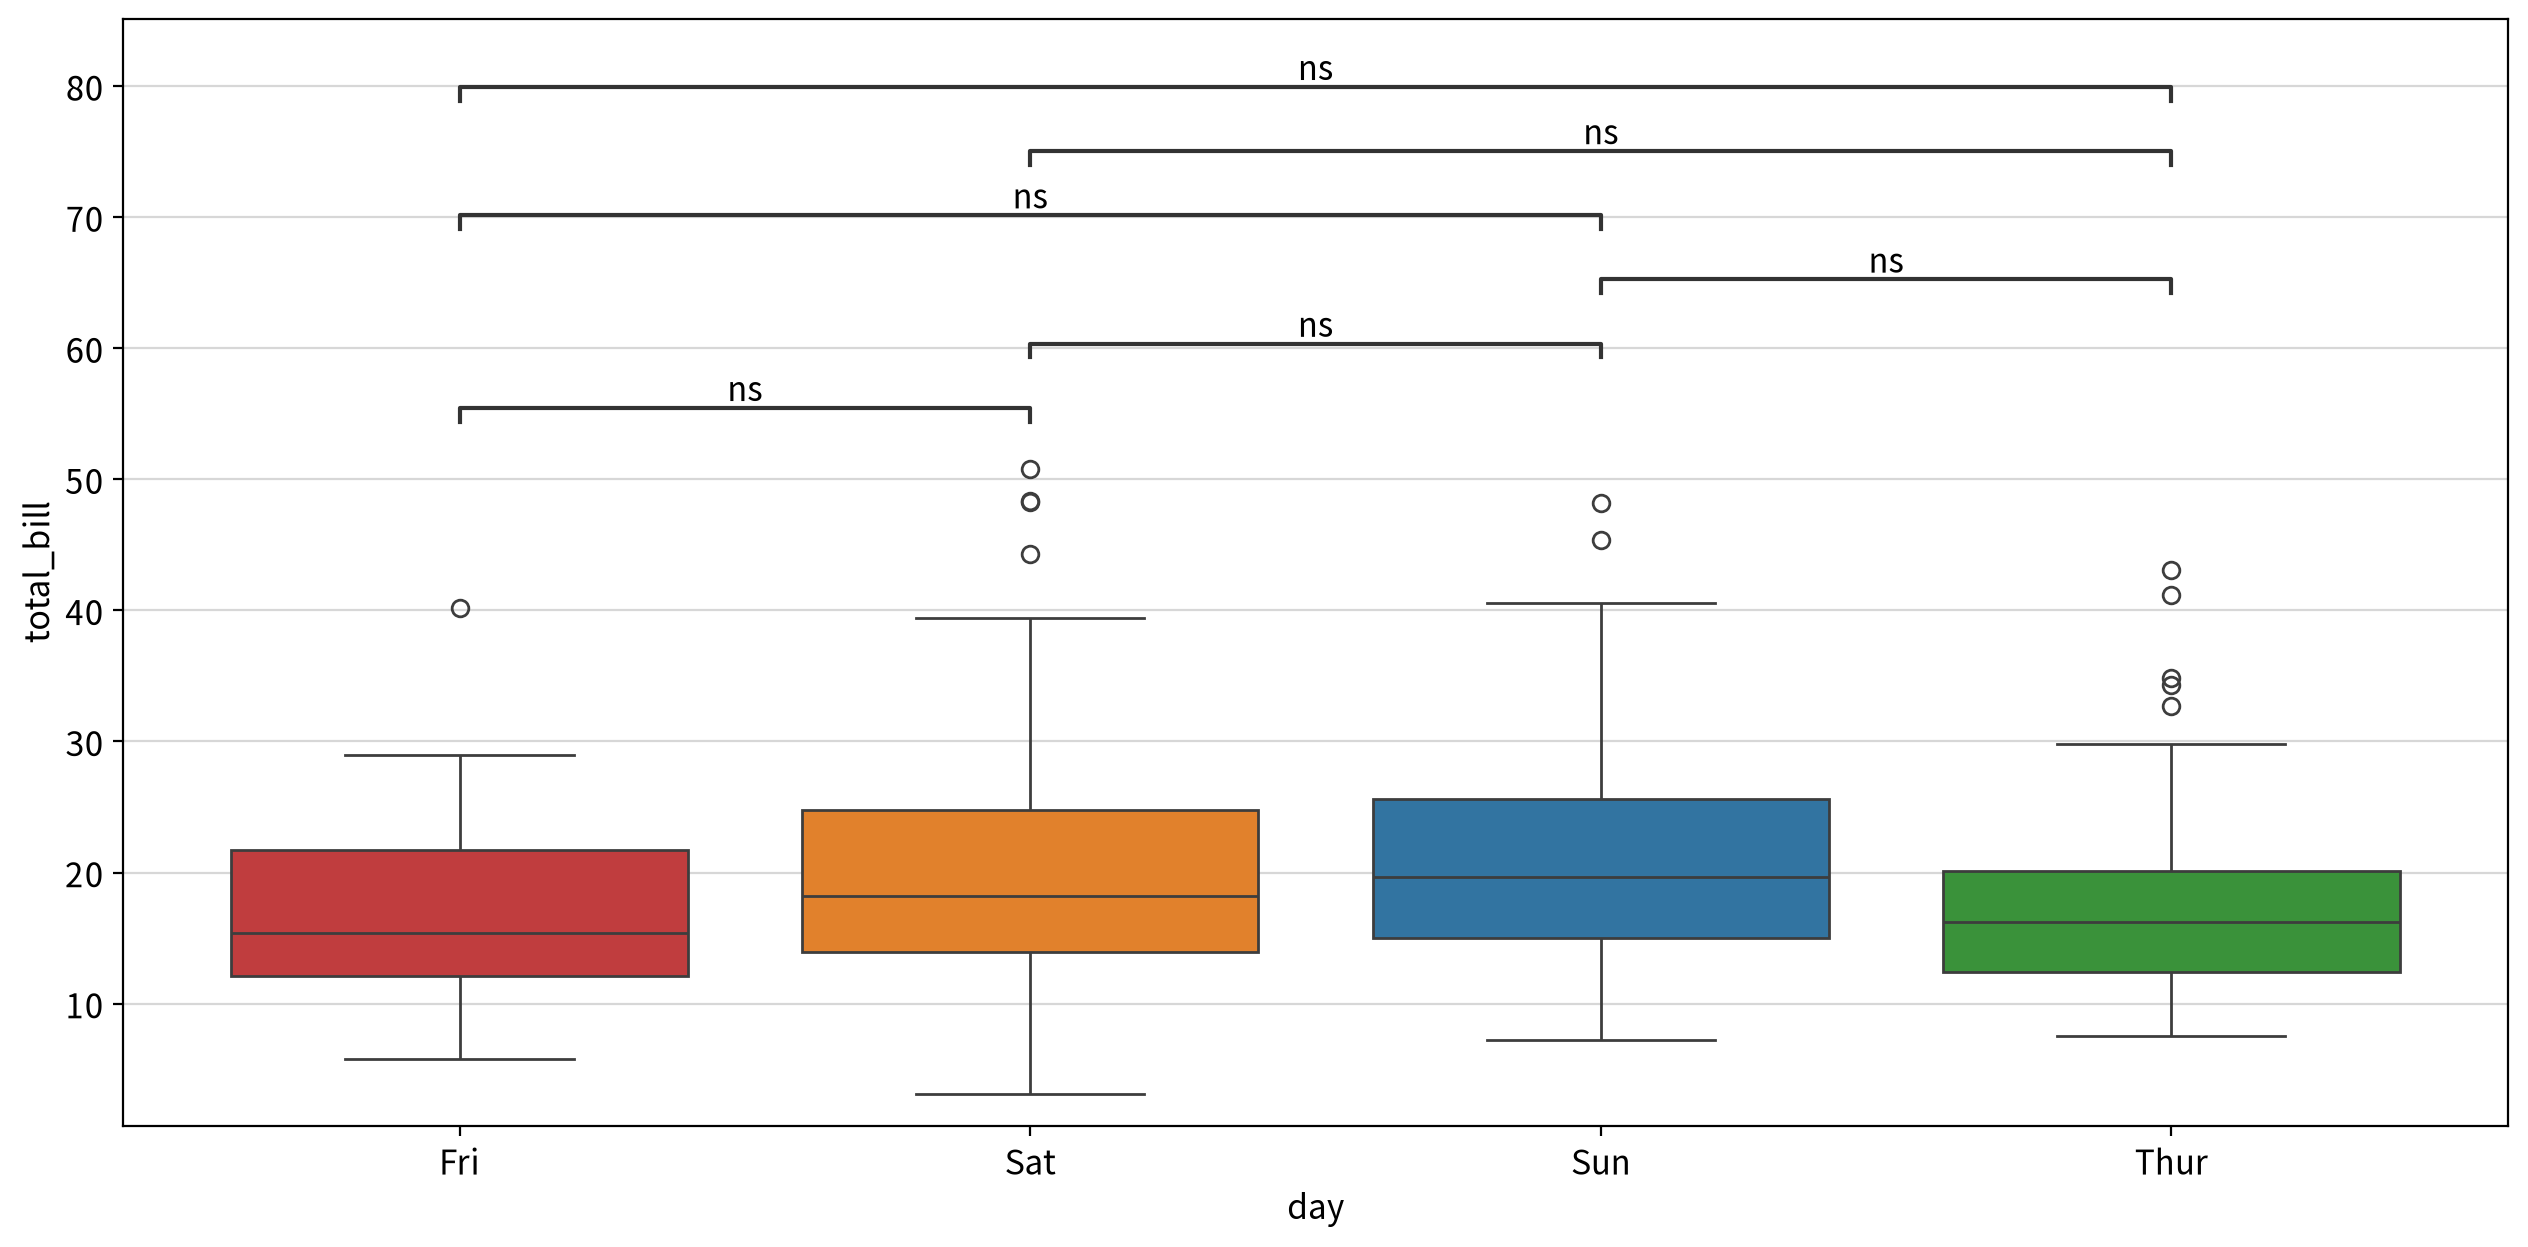

,test,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges,significant,effect_size
0,Tukey HSD,Fri,Sat,17.152,20.441,-3.290,2.230,-1.475,0.454,-0.352,False,Small
1,Tukey HSD,Fri,Sun,17.152,21.410,-4.258,2.259,-1.885,0.237,-0.484,False,Small
2,Tukey HSD,Fri,Thur,17.152,17.683,-0.531,2.309,-0.230,0.996,-0.066,False,Negligible
3,Tukey HSD,Sat,Sun,20.441,21.410,-0.969,1.383,-0.700,0.897,-0.105,False,Negligible
4,Tukey HSD,Sat,Thur,20.441,17.683,2.759,1.464,1.885,0.237,0.310,False,Small
5,Tukey HSD,Sun,Thur,21.410,17.683,3.727,1.507,2.473,0.067,0.440,False,Small


In [8]:
my_stats.posthoc_oneway(df4, y='total_bill', between='day')

### 💡인사이트

- **가정 확인**: 사후검정 결과표의 `test`가 **`Tukey HSD`**로 출력되었으므로 요일별 주문금액의 **등분산성 가정이 충족**되어, 일반 분산분석(`anova`)과 Tukey HSD 사후검정이 사용되었다.
- **분산분석 결과**: F(3, 240) = 2.767, p = 0.042 로 유의수준 0.05보다 작아 **전체적으로는 요일 간 차이가 유의**하다고 판단된다. 다만 효과크기 np2 = 0.033(**Small**)로 그 차이의 크기는 매우 작다.
- **구체적 차이**: **모든 요일 쌍의 p값이 0.05보다 커서 어떤 쌍도 통계적으로 유의하지 않다.** 가장 근접한 쌍도 Sun vs Thur(p = 0.067)로 유의수준을 넘지 못했고, 효과크기 역시 전부 Small~Negligible 수준이다.
- **결론**: 분산분석은 "차이가 있다"(p = 0.042)고 했지만, 더 보수적인 **사후검정에서는 구체적으로 차이가 나는 요일 쌍을 찾지 못했다.** 이는 경계적인 p값(0.042)과 작은 효과크기(np2 = 0.033) 때문으로, **요일에 따른 주문금액 차이는 실질적으로 미미하다**고 해석하는 것이 타당하다. (전체 검정과 사후검정 결론이 엇갈릴 수 있는 전형적 사례)
